---
<a id="top"></a>
# Tutorial: PSMD for Inventory Control
---
This notebook is a compact, end-to-end tutorial on a lightweight PSMD implementation for the same single-product inventory MDP used elsewhere in the project. The goal is to present PSMD in the same teaching style as the self-guided ALP notebook: explicit setup, clear notation, readable parameter blocks, and plots that separate current-iterate behavior from best-historical behavior.

**Learning goals**
- understand what the PSMD iterate is optimizing in the tutorial inventory problem
- see how the polynomial basis `[1, s, s^2]` enters the value-function approximation
- reproduce lower-bound and policy-cost curves for the same inventory instance
- interpret why current PSMD diagnostics can be nonmonotone while best-historical diagnostics improve

**Project and authors**
- Co-authors: [Andre Cire](https://utsc.utoronto.ca/mgmt/andre-cire), [Selva Nadarajah](https://selvan.people.uic.edu/), [Parshan Pakiman](https://parshanpakiman.github.io/), [Negar Soheili](https://www.negar-soheili.com/)
- GitHub: [self-adapting-mdp-approximations/informs-tutorials](https://github.com/self-adapting-mdp-approximations/informs-tutorials)



---
<a id="toc"></a>
## Table of Contents

1. [Setup](#setup)
2. [Imports and Shared Style](#imports)
3. [Constraint-Violation and Gibbs Density Plots](#constraint-violation-plots)
4. [Constraint-Threshold Heat Map](#constraint-threshold)
5. [Gibbs Density for CVL](#gibbs-density)
6. [Problem Map and Notation](#notation)
7. [PSMD Experiment](#psmd-exp)
8. [PSMD Summary Table](#summary)
9. [PSMD Iteration Plots](#plots)
10. [Sampler and Value-Function Diagnostics](#diagnostics)
11. [Understanding the Constraint Learning Mechanism](#constraint-learning)
12. [Interpretation](#interpretation)

---
<a id="setup"></a>
## 1. Setup

Run the next cell once if you want the notebook to create a lightweight local environment. If the dependencies are already installed, you can skip it. The package list mirrors the tutorial notebooks and adds nothing special beyond what the PSMD example needs.

In [1]:
%%bash

if python3 - <<'PY_DEPENDENCIES'
import importlib.util
required = ["numpy", "scipy", "matplotlib", "emcee"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
raise SystemExit(1 if missing else 0)
PY_DEPENDENCIES
then
    echo "Core tutorial dependencies already available; skipping environment setup."
    exit 0
fi

echo "Building a Python environment ..."
python3 -m venv ../.venv >/dev/null 2>&1
source ../.venv/bin/activate
python -m pip install --upgrade pip >/dev/null 2>&1
python -m pip install numpy scipy matplotlib emcee jupyter ipykernel >/dev/null 2>&1
echo "All done."


Building a Python environment ...
All done.


<a id="imports"></a>
## 2. Imports and Shared Style

Like the self-guided ALP notebook, we first add the parent project folder to Python's import path. After that, we import the shared inventory model from the main folder, the PSMD implementation from the renamed `PSMD/` package, and the shared config dataclasses from `config.py`.

In [2]:
import sys
from pathlib import Path

import numpy as np


def find_project_root(start_path: Path) -> Path:
    """
    Find the tutorial project root by looking for the shared Python modules.

    Args:
        start_path: Directory from which to begin the upward search.
    """
    for candidate in (start_path, *start_path.parents):
        if (candidate / "helper.py").exists() and (candidate / "config.py").exists():
            return candidate
    raise RuntimeError("Could not locate the tutorial project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
REPOSITORY_ROOT = PROJECT_ROOT.parent
for import_root in [PROJECT_ROOT, REPOSITORY_ROOT]:
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))


from config import CONTINUOUS_MDP_NOTEBOOK_CONFIG, make_shared_evaluation_configs
from helper import (
    apply_tutorial_plot_style,
    make_inventory_violation_plot_data,
    run_psmd_seed_grid,
    plot_inventory_constraint_threshold_heatmap,
    plot_inventory_gibbs_densities,
    plot_psmd_iteration_diagnostics,
    plot_psmd_acceptance_and_value,
    plot_psmd_sampling_snapshots,
)

apply_tutorial_plot_style()

tutorial_config = CONTINUOUS_MDP_NOTEBOOK_CONFIG
shared_lower_bound_config, shared_policy_config = make_shared_evaluation_configs()


---
<a id="constraint-violation-plots"></a>
## 3. Constraint-Violation and Gibbs Density Plots

Before running PSMD, we visualize the constraint-learning problem it is designed to address. The state is the inventory position `s`, the action is the order quantity `a`, and the cost-form ALP constraint threshold is

$$
f(\beta;s,a)=\frac{1}{1-\gamma}\left(c(s,a)-\beta_1\left(s-\gamma\mathbb{E}[s'\mid s,a]\right)-\beta_2\left(s^2-\gamma\mathbb{E}[(s')^2\mid s,a]\right)\right).
$$

For the quadratic value-function approximation

$$
V(s;\beta)=\beta_0+\beta_1s+\beta_2s^2,
$$

the ALP constraint is `beta_0 <= f(beta; s, a)` for every feasible state-action pair. Small values of `f` are the tight regions of the semi-infinite constraint system.

In [3]:
VIOLATION_PLOT_NUM_CONSTRAINTS = tutorial_config.falp.num_constraints
VIOLATION_PLOT_NUM_STATE_RELEVANCE_SAMPLES = tutorial_config.falp.num_state_relevance_samples
VIOLATION_PLOT_REPRESENTATIVE_QUADRATIC_COEF = -2.0
VIOLATION_PLOT_STATE_GRID_SIZE = tutorial_config.policy_evaluation.state_grid_size
VIOLATION_PLOT_ACTION_GRID_SIZE = tutorial_config.policy_evaluation.state_grid_size

violation_plot_data = make_inventory_violation_plot_data(
    inventory_config=tutorial_config.inventory,
    num_constraints=VIOLATION_PLOT_NUM_CONSTRAINTS,
    num_state_relevance_samples=VIOLATION_PLOT_NUM_STATE_RELEVANCE_SAMPLES,
    representative_quadratic_coef=VIOLATION_PLOT_REPRESENTATIVE_QUADRATIC_COEF,
    state_grid_size=VIOLATION_PLOT_STATE_GRID_SIZE,
    action_grid_size=VIOLATION_PLOT_ACTION_GRID_SIZE,
)

fit = violation_plot_data.fit
sampled_slacks = fit.sampled_slacks
mdp = violation_plot_data.mdp

print('Inventory instance')
print('------------------')
print('state range:', (mdp.lower_state_bound, mdp.upper_state_bound))
print('action range:', (0.0, mdp.max_order))
print('discount:', mdp.discount)
print('demand sample size:', mdp.num_noise_samples)
print('basis:', '[1, s, s^2]')
print()
print('Representative beta')
print('-------------------')
print('sampled ALP beta:', fit.alp_beta)
print('heat-map beta:', violation_plot_data.beta)
print('ALP objective:', f'{fit.alp_objective:,.2f}')
print('minimum sampled slack:', f'{float(sampled_slacks.min()):.4g}')
print('binding sampled constraints:', int((sampled_slacks <= 1e-6).sum()))
print()
print('Threshold grid')
print('--------------')
print('grid shape:', violation_plot_data.threshold_values.shape)
print('minimum f value:', f'{violation_plot_data.min_value:,.2f}')
print('minimum location:', f's = {violation_plot_data.min_state:.2f}, a = {violation_plot_data.min_action:.2f}')


Inventory instance
------------------
state range: (-4.0, 12.0)
action range: (0.0, 6.0)
discount: 0.95
demand sample size: 1000
basis: [1, s, s^2]

Representative beta
-------------------
sampled ALP beta: [ 2.33470033e+03 -2.75702014e+01  4.93117179e-01]
heat-map beta: [ 2.33470033e+03  2.00000000e+00 -2.00000000e+00]
ALP objective: 2,243.23
minimum sampled slack: -2.38e-13
binding sampled constraints: 3

Threshold grid
--------------
grid shape: (2000, 2000)
minimum f value: 1,365.62
minimum location: s = 5.49, a = 0.46


---
<a id="constraint-threshold"></a>
## 4. Constraint-Threshold Heat Map

This figure shows where the ALP constraint is tight. Darker colors correspond to smaller values of `f(beta; s, a)`, so they identify the state-action pairs that most directly limit the feasible intercept `beta_0`. The compact, curved low-value region shows why a fixed uniform constraint-sampling rule can spend many samples in easy parts of the rectangle.

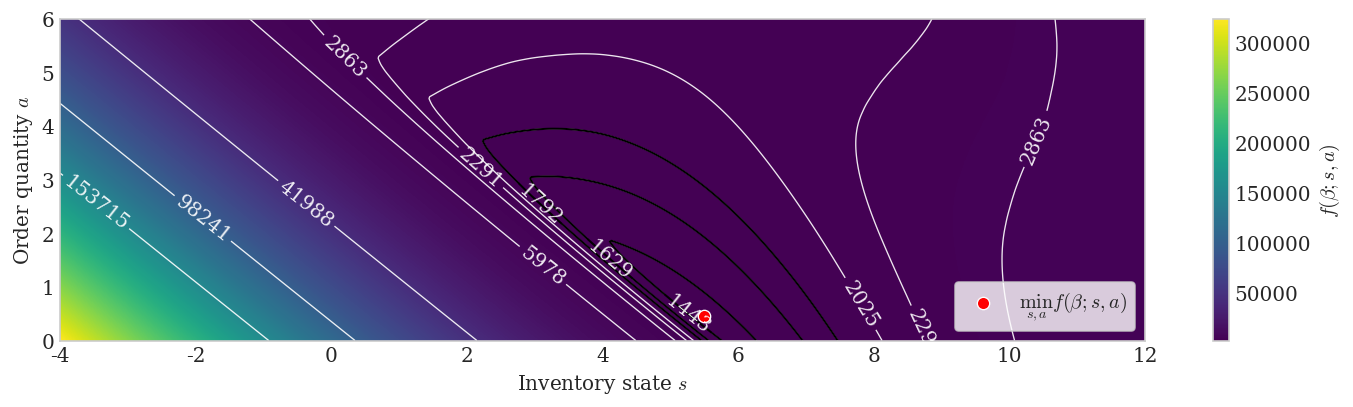

In [4]:
plot_inventory_constraint_threshold_heatmap(
    violation_plot_data,
    figsize=(12, 3.5),
    fontsize=12,
    cmap='viridis',
)

---
<a id="gibbs-density"></a>
## 5. Gibbs Density for CVL

Constraint-violation learning adds a KL penalty relative to the uniform density over the feasible state-action rectangle. For fixed `beta`, the regularized inner minimizer has the Gibbs form

$$
y^*_{\lambda,\beta}(s,a)
= \frac{\exp(-f(\beta;s,a)/\lambda)}{\int_{\mathcal S\times\mathcal A_s}\exp(-f(\beta;s',a')/\lambda)\,d(s',a')}.
$$

The code below approximates this density on the same grid and with the same colormap as the threshold heat map. Smaller `lambda` concentrates probability near the smallest values of `f`; larger `lambda` spreads probability over a broader high-violation region.

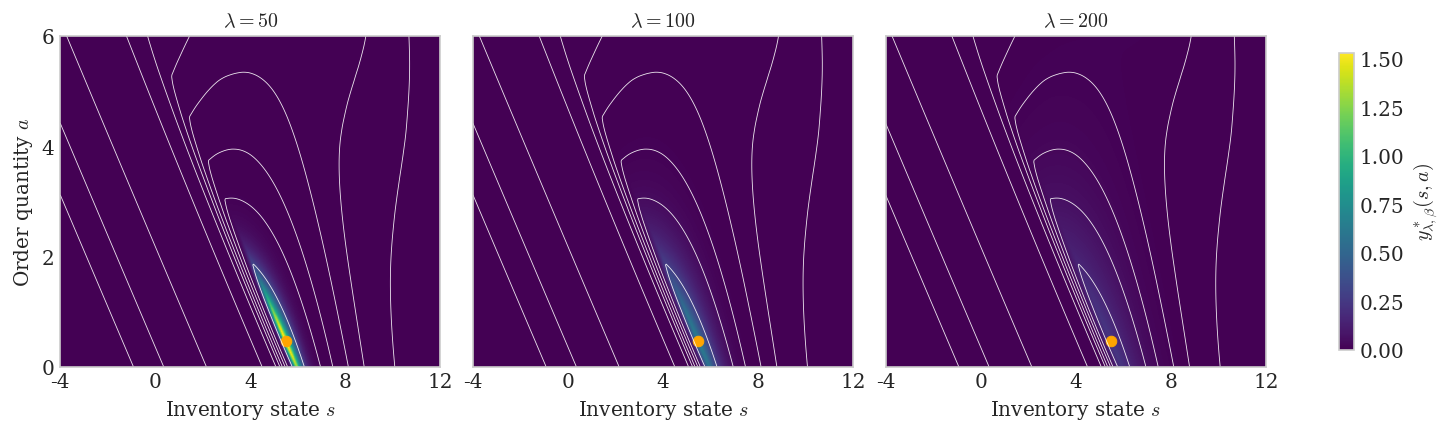

In [5]:
lambda_values = [50.0, 100.0, 200.0]
_, _, gibbs_densities = plot_inventory_gibbs_densities(
    violation_plot_data,
    lambda_values=lambda_values,
    figsize=(12, 3.5),
    fontsize=12,
    cmap='viridis',
)

<a id="notation"></a>
## 6. Problem Map and Notation

| Object | Meaning | Where it appears |
| --- | --- | --- |
| `s` | current inventory state | horizontal axis for the VFA plot |
| `a` | order quantity | chosen by the greedy policy induced by the PSMD iterate |
| `\hat V(s)` | approximate value function | represented by the polynomial basis `[1, s, s^2]` |
| `H` | number of state-action samples used in each PSMD update | controls the outer sample size |
| `N` | number of demand draws per sampled state-action pair | controls the Bellman expectation estimate |
| lower bound | sampling-based certificate built from the averaged PSMD iterate | should increase as the approximation improves |
| policy cost | simulated cost of the greedy policy induced by the averaged iterate | should decrease as the policy improves |
| best historical bound/cost | incumbent lower and upper bounds across all evaluated iterations | smoother view of PSMD progress |

The inventory instance is fixed throughout the notebook. What changes across PSMD iterations is the approximate value function and the learned violation-focused state-action distribution.

---
<a id="psmd-exp"></a>
## 7. PSMD Experiment

We now solve the tutorial inventory instance with the simplified PSMD routine. To match the self-guided ALP notebook more closely, we run PSMD on the same comparison-style seed grid, using seeds `111`, `222`, `333`, `444`, and `555`.

The design choices are made explicit in one config object:

- the basis is the requested polynomial basis with constant, linear, and quadratic terms
- the PSMD batch sizes are fixed at `H = 10` and `N = 50`
- the violation sampler uses random-walk Metropolis-Hastings rather than Langevin dynamics
- the lower-bound Monte Carlo and policy-evaluation settings are aligned with the self-guided notebook so the comparisons stay apples-to-apples
- we evaluate lower and upper bounds every `200` iterations so the output stays easy to read

This is the expensive cell. Run it once and reuse the cached `psmd_results` below. Like the FALP tutorial block, it prints per-seed PSMD diagnostics as the runs complete.

In [6]:
psmd_seed_grid = list(tutorial_config.seeds)
plot_seed = psmd_seed_grid[0]
psmd_config = tutorial_config.psmd

psmd_results = run_psmd_seed_grid(
    seeds=psmd_seed_grid,
    psmd_config=psmd_config,
    inventory_config=tutorial_config.inventory,
    verbose=True,
)

plot_result = psmd_results[plot_seed]
solver = plot_result["model"]
solution = plot_result["solution"]


    seed     iter  lower bound  policy cost      best lb      best pc      gap %    acc. rate   time (sec)
------------------------------------------------------------------------------------------------------------
     111        1     -27666.7       3772.8     -27666.7       3772.8      833.3          0.5          9.6
     111      300       1074.0       3772.8       1074.0       3772.8       71.5          0.4         21.7
     111      600       1608.5       3772.8       1608.5       3772.8       57.4          0.4         32.5
     111      900       1763.9       3773.6       1763.9       3772.8       53.2          0.4         44.6
     111     1200       1837.2       3791.8       1837.2       3772.8       51.3          0.4         55.9
     111     1500       1878.1       3824.5       1878.1       3772.8       50.2          0.3         67.8
------------------------------------------------------------------------------------------------------------
     222        1     -28561.2   

---
<a id="summary"></a>
## 8. PSMD Summary Table

The experiment cell above prints one row per seed after each PSMD run completes. The table reports the final lower bound, policy cost, incumbent best values, optimality gap, sampler acceptance rate, and runtime. The plots below use the same cached `psmd_results` object, so no additional PSMD fitting is needed.

---
<a id="plots"></a>
## 9. PSMD Bound Plots

The next figure keeps the iteration-based PSMD view, but now each evaluated iteration is summarized across seeds `111`, `222`, `333`, `444`, and `555` with box plots.
- left: current lower bounds and policy costs across seeds at each evaluated iteration
- right: best-historical lower bounds and best-historical policy costs across seeds at each evaluated iteration

This preserves the original paper-style question, namely how the bounds evolve over iterations, while still making the seed-to-seed variation visible.

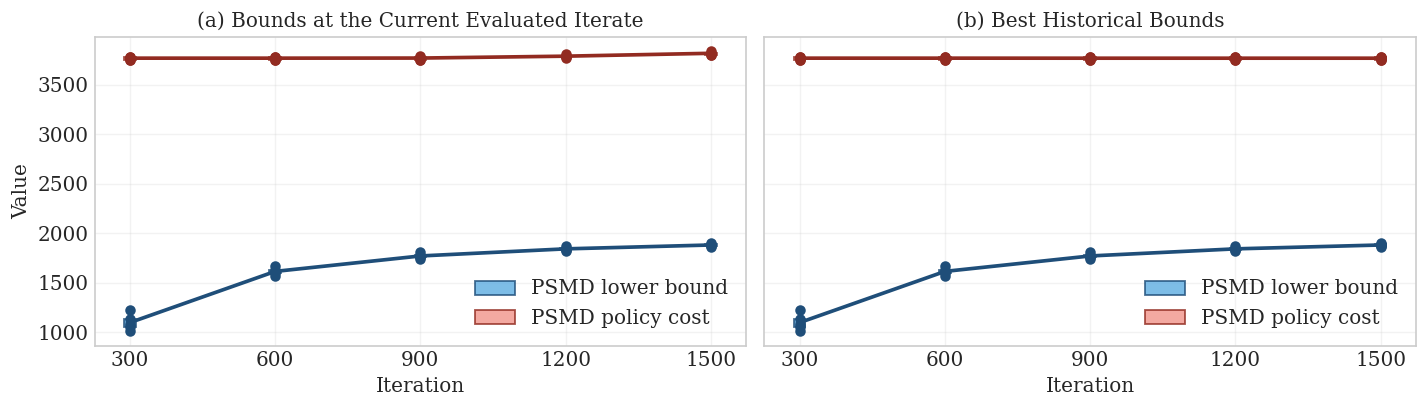

In [7]:
plot_psmd_iteration_diagnostics(
    psmd_results,
    psmd_seed_grid,
    min_iteration=200,
)


---
<a id="diagnostics"></a>
## 10. Sampler and Value-Function Diagnostics

It is useful to inspect one more layer of diagnostics beyond the main bound figure for representative seed `111`:
- the acceptance rate of the Metropolis-Hastings violation sampler
- the approximate value function implied by the final averaged PSMD iterate

These are not part of the main figure, but they help explain whether the sampler is moving enough and what shape the learned value approximation is taking.

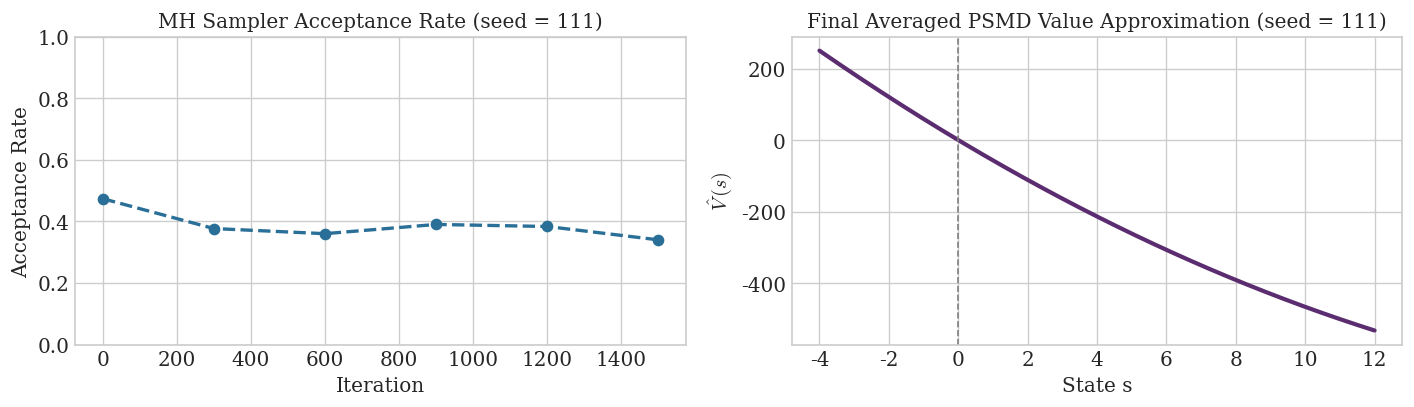

In [8]:
plot_psmd_acceptance_and_value(
    plot_result,
    plot_seed,
    grid_size=300,
)


---
<a id="constraint-learning"></a>
## 11. Understanding the Constraint Learning Mechanism

The main PSMD idea is not just the coefficient update. It is also the adaptive state-action sampling rule `y_t` that shifts attention toward regions with large Bellman-constraint violations.

The next figure mirrors the diagnostic in the paper-style screenshot you shared. We evolve a persistent diagnostic cloud of `100` state-action particles under the same Metropolis-Hastings violation sampler used by PSMD for representative seed `111`, and we save that cloud at a sequence of iterations:

- iteration `0` starts from a diffuse, nearly uniform prior over feasible state-action pairs
- later panels show how the Metropolis-Hastings sampler concentrates around the state-action region that appears most informative for constraint correction
- when this concentration sharpens quickly, PSMD usually makes its largest lower-bound improvements


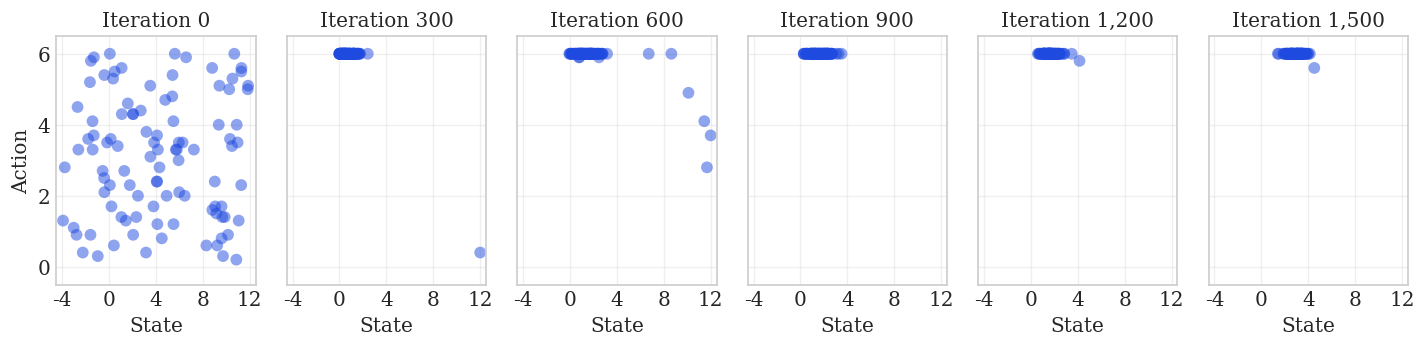

In [9]:
plot_psmd_sampling_snapshots(
    plot_result,
    plot_seed,
)


---
<a id="interpretation"></a>
## 12. Interpretation

A few takeaways are worth emphasizing.

- The basis is deliberately simple: the constant term, the linear term, and the quadratic term `s^2`. That keeps the PSMD tutorial close to the description you provided and makes the resulting VFA easy to interpret.
- Running PSMD on seeds `111`, `222`, `333`, `444`, and `555` puts it on the same comparison footing as the self-guided tutorial. The summary table and the iteration-by-iteration box plots should be read across seeds, while the later diagnostics focus on one representative trajectory.
- The current lower bound and policy cost are not monotone over PSMD iterations. That is expected because the coefficients are updated using stochastic gradient information and a learned state-action sampling distribution.
- The bound figure now preserves the iteration axis from the original PSMD presentation, but each iteration is summarized with a seed box plot instead of a single-seed point estimate. That makes the progression visible without hiding seed variation.
- The sampler is important. Even in this lightweight Metropolis-Hastings version, the quality of the PSMD updates depends on how quickly the state-action distribution shifts toward high-violation regions.

---